### NSL-KDD Intrusion Detection - Data Preprocessing & ML Models

This notebook demonstrates a full workflow on the NSL-KDD dataset, covering preprocessing, scaling, training, and evaluating multiple ML models. The goal is to classify network traffic as either "normal" or an "attack."

-----

### Steps covered:

  - Load and explore dataset
  - Clean missing and duplicate rows
  - Handle categorical features with one-hot encoding
  - Normalize features using StandardScaler
  - Create binary target (Normal vs Attack)
  - Split into train & test sets
  - Train multiple ML models
  - Evaluate and compare performance

-----

### Step 1: Load and Explore Dataset

The NSL-KDD dataset has 41 features plus one target class feature. The training set has no redundant records, so classifiers will not be biased towards more frequent records. The test set also lacks duplicate records, ensuring unbiased performance evaluation.

In [13]:
# Import pandas library
import pandas as pd

# Define dataset columns from NSL-KDD
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'outcome','level'
]

# Load Train & Test data
train_df = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTrain+.txt", names=columns)
test_df  = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTest+.txt", names=columns)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


-----

### Step 2: Feature Engineering and Data Exploration

New features are created to simplify the classification task. The **`outcome`** column is converted into a binary **`binary_label`** column (`normal` vs. `attack`). The specific attack types are then mapped to broader **`attack_category`** categories like **`DoS`**, **`Probe`**, **`R2L`**, and **`U2R`**. The distribution of these new categories is visualized using bar plots for both the training and test datasets.

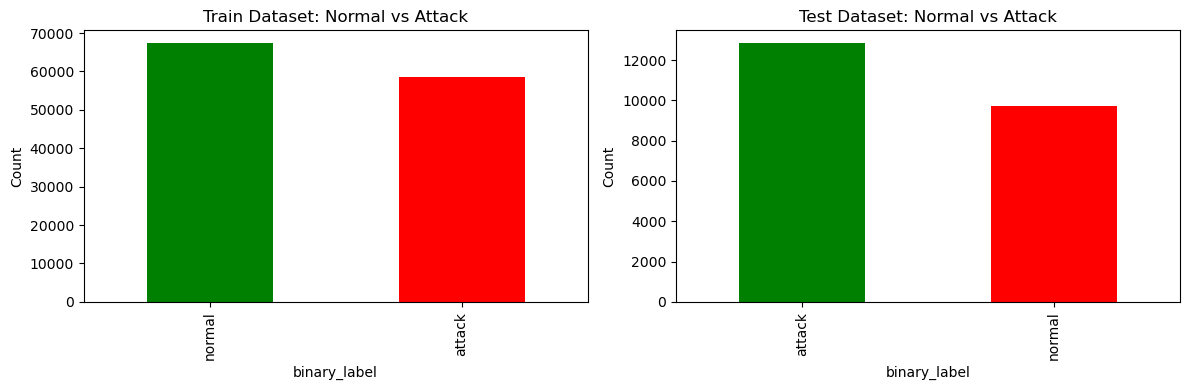

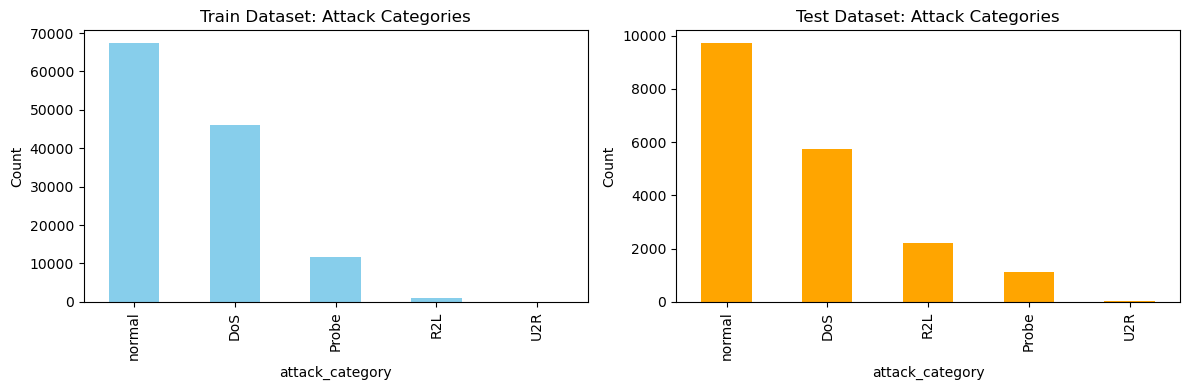

In [14]:
# Create binary column: normal vs attack
train_df['binary_label'] = train_df['outcome'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_df['binary_label']  = test_df['outcome'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# Define attack categories for mapping
attack_category = {
    'normal': 'normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

# Map attack_category column and check unique values
train_df['attack_category'] = train_df['outcome'].map(attack_category)
test_df['attack_category']  = test_df['outcome'].map(attack_category)

# Plotting the distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of binary labels
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
train_df['binary_label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Train Dataset: Normal vs Attack")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
test_df['binary_label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Test Dataset: Normal vs Attack")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot distribution of attack categories
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
train_df['attack_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Train Dataset: Attack Categories")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
test_df['attack_category'].value_counts().plot(kind='bar', color='orange')
plt.title("Test Dataset: Attack Categories")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

-----

### Step 3: Data Cleaning

This step involves handling missing values, duplicates, and outliers to prepare the data for modeling.

  - **Handle Missing Values**: Any missing values in the numeric columns are filled with `0`. Missing values in categorical columns are filled with `'unknown'`. A heatmap is used to visually confirm that no missing values remain.
  - **Remove Duplicate Rows**: Duplicate rows are identified and removed from both the training and test datasets to ensure data integrity.
  - **Outlier Treatment**: Outliers in selected numeric features (**`duration`**, **`src_bytes`**, **`dst_bytes`**) are handled by capping them at the upper and lower bounds calculated using the Interquartile Range (IQR) method.

<!-- end list -->

Missing values in Train dataset:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

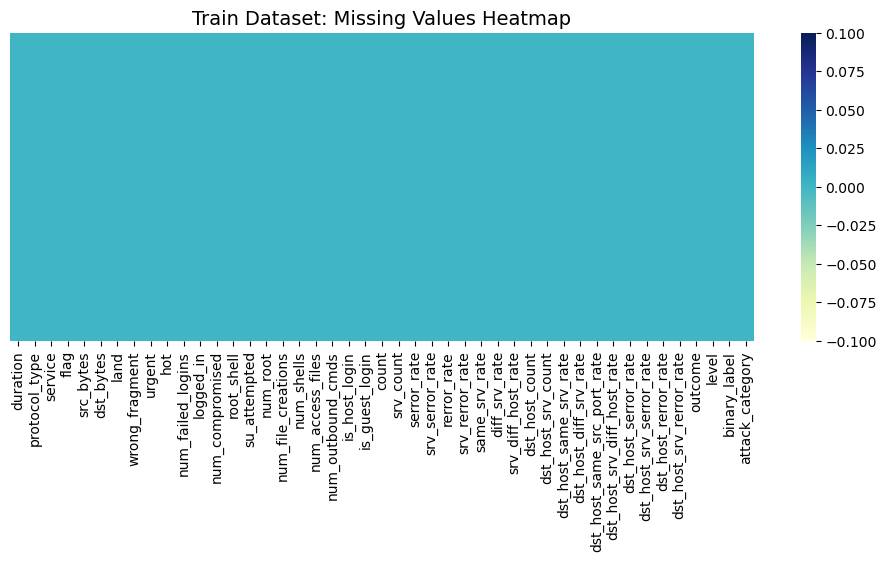

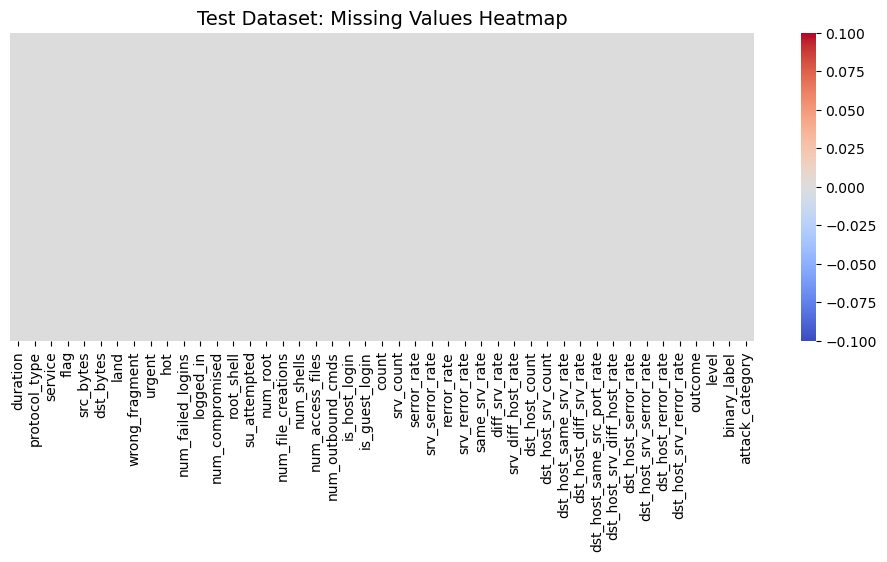

Duplicate rows in Train: 0
Duplicate rows in Test: 0
After removing duplicates:
Train shape: (125973, 45)
Test shape: (22544, 45)


,duration,src_bytes,dst_bytes
count,125973.0,125973.000000,125973.000000
mean,0.0,170.842220,343.631080
std,0.0,224.072682,508.842646
min,0.0,0.000000,0.000000
25%,0.0,0.000000,0.000000
50%,0.0,44.000000,0.000000
75%,0.0,276.000000,516.000000
max,0.0,690.000000,1290.000000


In [15]:
# Check and handle missing values
print("Missing values in Train dataset:")
print(train_df.isnull().sum())
print("\nMissing values in Test dataset:")
print(test_df.isnull().sum())

# Fill missing values
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns
train_df[numeric_cols] = train_df[numeric_cols].fillna(0)
test_df[numeric_cols]  = test_df[numeric_cols].fillna(0)
categorical_cols = train_df.select_dtypes(include=['object']).columns
train_df[categorical_cols] = train_df[categorical_cols].fillna('unknown')
test_df[categorical_cols]  = test_df[categorical_cols].fillna('unknown')

# Plot heatmaps to verify missing values are gone
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
sns.heatmap(train_df.isnull(), cmap="YlGnBu", cbar=True, yticklabels=False)
plt.title("Train Dataset: Missing Values Heatmap", fontsize=14)
plt.show()

plt.figure(figsize=(12, 4))
sns.heatmap(test_df.isnull(), cmap="coolwarm", cbar=True, yticklabels=False)
plt.title("Test Dataset: Missing Values Heatmap", fontsize=14)
plt.show()

# Check and remove duplicates
print("Duplicate rows in Train:", train_df.duplicated().sum())
print("Duplicate rows in Test:", test_df.duplicated().sum())

train_df = train_df.drop_duplicates()
test_df  = test_df.drop_duplicates()

print("After removing duplicates:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Cap outliers using IQR method for specific numeric columns
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].apply(lambda x: lower if x < lower else (upper if x > upper else x))
    return df

numeric_cols_to_cap = ['duration', 'src_bytes', 'dst_bytes']
train_df = cap_outliers_iqr(train_df, numeric_cols_to_cap)
test_df = cap_outliers_iqr(test_df, numeric_cols_to_cap)

# Check the new distribution
train_df[numeric_cols_to_cap].describe()

 Step -4:Feature Scaling Using StandardScaler

Numeric features are standardized to mean 0 and standard deviation 1 to ensure all features contribute equally to the model. This step improves stability and performance for models sensitive to feature magnitudes. 

In [16]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns
numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot']

# Initialize scaler
scaler = StandardScaler()

# Fit on train data & transform train
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])

# Transform test data using the same scaler
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

# Check first few rows
print(train_df[numeric_cols].head())


   duration  src_bytes  dst_bytes  wrong_fragment    urgent       hot
0       0.0   1.428818  -0.675322       -0.089486 -0.007736 -0.095076
1       0.0  -0.110867  -0.675322       -0.089486 -0.007736 -0.095076
2       0.0  -0.762444  -0.675322       -0.089486 -0.007736 -0.095076
3       0.0   0.272938   1.859853       -0.089486 -0.007736 -0.095076
4       0.0   0.125664   0.150084       -0.089486 -0.007736 -0.095076


-----

### Step :5 Handle Categorical Features with One-Hot Encoding

Since many machine learning models cannot directly process categorical data, it must be converted into a numerical format. The categorical features **`protocol_type`**, **`service`**, and **`flag`** are transformed using **One-Hot Encoding**. This technique creates new binary columns for each unique category, representing the data as 0s and 1s.

In [17]:
# Categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# One-Hot Encoding using pandas
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df  = pd.get_dummies(test_df, columns=categorical_cols)

# Align train and test columns to ensure consistent features
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# Check shapes after encoding
print("Train shape after One-Hot Encoding:", train_df.shape)
print("Test shape after One-Hot Encoding :", test_df.shape)

# Check the first few rows of the one-hot encoded features
onehot_cols = [col for col in train_df.columns if '_' in col]
train_df[onehot_cols].head()

Train shape after One-Hot Encoding: (125973, 126)
Test shape after One-Hot Encoding : (22544, 126)


,src_bytes,dst_bytes,wrong_fragment,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,1.428818,-0.675322,-0.089486,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,-0.110867,-0.675322,-0.089486,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,-0.762444,-0.675322,-0.089486,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0.272938,1.859853,-0.089486,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,0.125664,0.150084,-0.089486,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False


-----

### Step 6: Create a Binary Target (Normal vs. Attack)

The original dataset has various attack types. For a binary classification task, the **`outcome`** column is converted into a binary **`binary_label`** column where 'normal' is mapped to `0` and all other attack types are mapped to `1`. This new column will serve as the target variable for the models.

In [18]:
# Map binary_label to numeric
train_df['binary_label_num'] = train_df['binary_label'].map({'normal':0, 'attack':1}).astype(int)
test_df['binary_label_num']  = test_df['binary_label'].map({'normal':0, 'attack':1}).astype(int)

# Check
print(train_df[['binary_label','binary_label_num']].head())

  binary_label  binary_label_num
0       normal                 0
1       normal                 0
2       attack                 1
3       normal                 0
4       normal                 0


-----

### Step 7: Split into Train & Test Sets

The dataset is already provided with separate training and test sets. The features (**`X`**) are separated from the target variable (**`y`**) for both the training and test data. This is an important step for building and evaluating a machine learning model.

In [19]:
# Separate features and target
X_train = train_df.drop(['binary_label', 'attack_category', 'level', 'binary_label_num', 'outcome'], axis=1)
y_train = train_df['binary_label_num']
X_test  = test_df.drop(['binary_label', 'attack_category', 'level', 'binary_label_num', 'outcome'], axis=1)
y_test  = test_df['binary_label_num']

# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (125973, 122)
y_train shape: (125973,)
X_test shape : (22544, 122)
y_test shape : (22544,)


-----

### Step 8: Handle Data Imbalance and Feature Scaling

The NSL-KDD training data has an imbalanced class distribution, with more 'normal' samples than 'attack' samples. To address this, we use the **Synthetic Minority Over-sampling Technique (SMOTE)** to generate synthetic samples for the minority class, thus balancing the dataset. Following that, **StandardScaler** is used to normalize the features for optimal model training.

In [20]:
# Handle Data Imbalance using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original training distribution:\n", y_train.value_counts())
print("\nAfter SMOTE (training data balanced):\n", y_train_res.value_counts())
print("\nTest set distribution (unchanged):\n", y_test.value_counts())

# Feature Scaling Only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on SMOTE-balanced training data and transform
X_train_scaled = scaler.fit_transform(X_train_res)

# Transform test set using same scaler
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Original training distribution:
 binary_label_num
0    67343
1    58630
Name: count, dtype: int64

After SMOTE (training data balanced):
 binary_label_num
0    67343
1    67343
Name: count, dtype: int64

Test set distribution (unchanged):
 binary_label_num
1    12833
0     9711
Name: count, dtype: int64
X_train_scaled shape: (134686, 122)
X_test_scaled shape: (22544, 122)


-----

### Step 9: Train Multiple ML Models

A dictionary of machine learning models is created to train and evaluate different algorithms. The models selected for this task are **Logistic Regression**, **Decision Tree**, **Random Forest**, and **Gradient Boosting**. They are trained on the preprocessed training data.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_res)
    print(f"{name} trained.\n")

Training Logistic Regression...
Logistic Regression trained.

Training Decision Tree...
Decision Tree trained.

Training Random Forest...
Random Forest trained.

Training Gradient Boosting...
Gradient Boosting trained.



-----

### Step 10: Evaluate and Compare Performance

Finally, the trained models are evaluated on the unseen test set. Performance metrics such as **accuracy** and a **classification report** (which includes precision, recall, and F1-score) are used to assess each model's effectiveness. A bar plot is then used to visually compare the accuracy of all the models, providing a clear summary of their performance.

In [22]:
from sklearn.metrics import accuracy_score, classification_report

# Dictionary to store results
results = {}

# Evaluate each trained model
for name, model in models.items():
    print("="*60)
    print(f"Evaluating {name}...")
    
    # Training accuracy
    y_train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train_res, y_train_pred)
    
    # Testing accuracy
    y_test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Save results
    results[name] = {"Train Accuracy": train_acc, "Test Accuracy": test_acc}
    
    # Print results
    print(f"{name} - Train Accuracy: {train_acc*100:.2f}%")
    print(f"{name} - Test Accuracy: {test_acc*100:.2f}%\n")
    print("Classification Report (Test Data):")
    print(classification_report(y_test, y_test_pred, target_names=['Normal','Attack']))
    print("="*60)

# Show final results neatly
import pandas as pd
results_df = pd.DataFrame(results).T
print("\nModel Performance Summary:")
print(results_df)


Evaluating Logistic Regression...
Logistic Regression - Train Accuracy: 97.60%
Logistic Regression - Test Accuracy: 75.73%

Classification Report (Test Data):
              precision    recall  f1-score   support

      Normal       0.65      0.92      0.77      9711
      Attack       0.92      0.63      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.80      0.76      0.76     22544

Evaluating Decision Tree...
Decision Tree - Train Accuracy: 99.99%
Decision Tree - Test Accuracy: 80.76%

Classification Report (Test Data):
              precision    recall  f1-score   support

      Normal       0.70      0.96      0.81      9711
      Attack       0.96      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544

Evaluating Random Forest...
Random Forest - Tr

## **Step 11: Confusion Matrix Visualization**

The **confusion matrix** shows how many samples were correctly and incorrectly classified:

- **Top-left (True Normal):** Normal traffic correctly predicted as Normal.  
- **Bottom-right (True Attack):** Attack traffic correctly predicted as Attack.  
- **Top-right (False Attack):** Normal traffic misclassified as Attack.  
- **Bottom-left (False Normal):** Attack traffic misclassified as Normal.  

This helps to analyze **model performance beyond accuracy**.


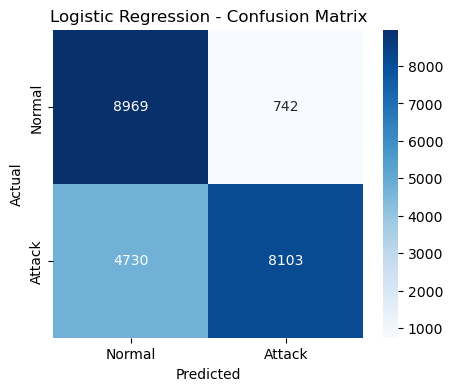

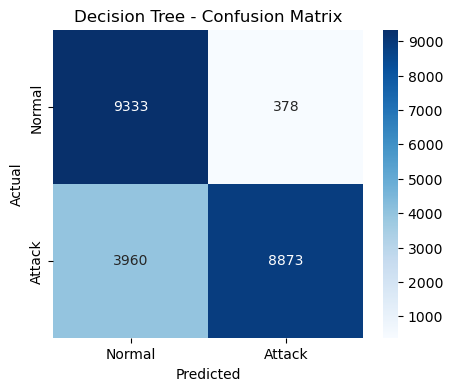

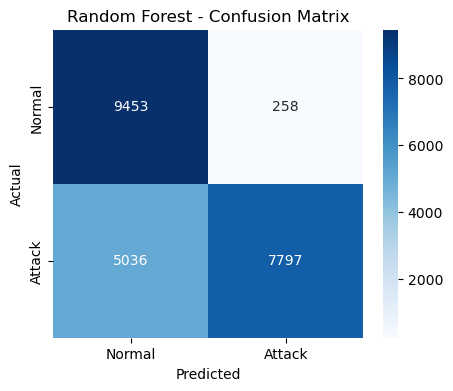

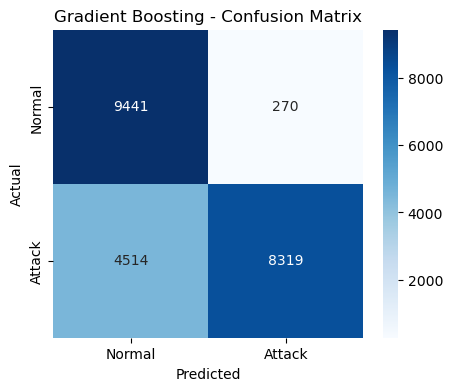

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Confusion Matrices for Each Model
# -------------------------------
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


## **Step 12: ROC Curve and AUC Analysis**

The **ROC (Receiver Operating Characteristic) curve** helps visualize the trade-off between **True Positive Rate (TPR)** and **False Positive Rate (FPR)** for a classifier.  

- **TPR (Recall):** How many attacks are correctly detected.  
- **FPR:** How many normal samples are incorrectly classified as attacks.  

The **AUC (Area Under Curve)** measures the overall ability of the model to distinguish between classes:  
- **AUC = 1.0:** Perfect model.  
- **AUC = 0.5:** Random guessing.  
- **Higher AUC → Better performance.**


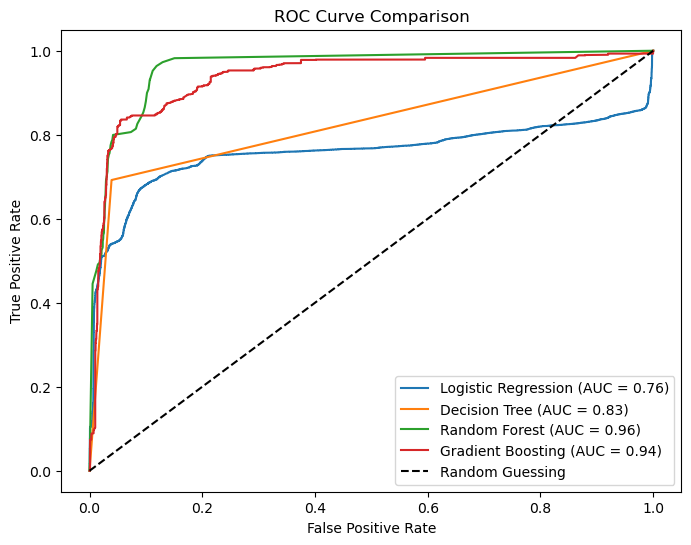

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Predict probabilities (for ROC)
    y_probs = model.predict_proba(X_test_scaled)[:,1]  # take probability for class 1 (Attack)
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random Guessing')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()


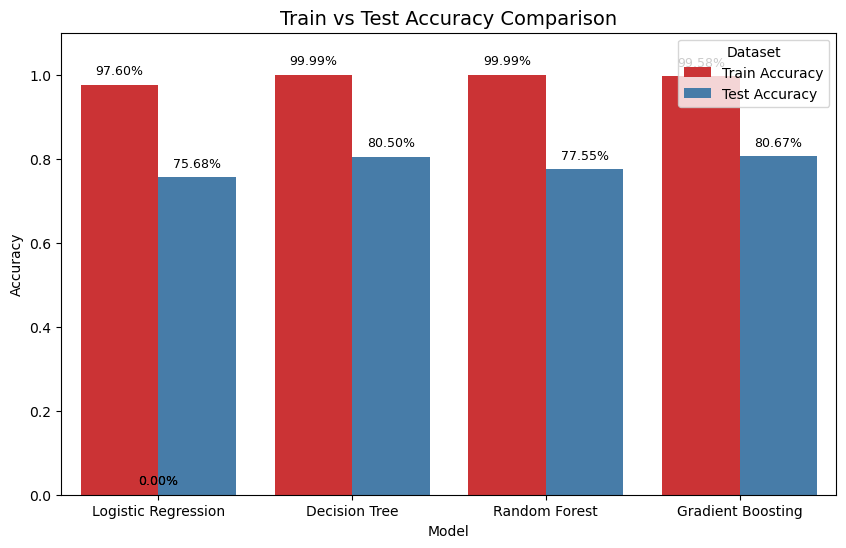

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dict to DataFrame
results_df = pd.DataFrame(results).T.reset_index()
results_df.rename(columns={"index": "Model"}, inplace=True)

# Plot Train vs Test Accuracy
plt.figure(figsize=(10,6))
results_df_melted = results_df.melt(id_vars="Model", var_name="Dataset", value_name="Accuracy")

sns.barplot(x="Model", y="Accuracy", hue="Dataset", data=results_df_melted, palette="Set1")

# Add labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()*100:.2f}%',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom',
                       fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.ylim(0, 1.1)
plt.title("Train vs Test Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.show()
